# Iris Flower Species Classification

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arshid/iris-flower-dataset/IRIS.csv")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Basic Data

In [3]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

print("\nMissing Values:")
df.isnull().sum()


Dataset Shape: (150, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistical Summary:

Missing Values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Exploratory Data Analysis (EDA)

# Class Distribution

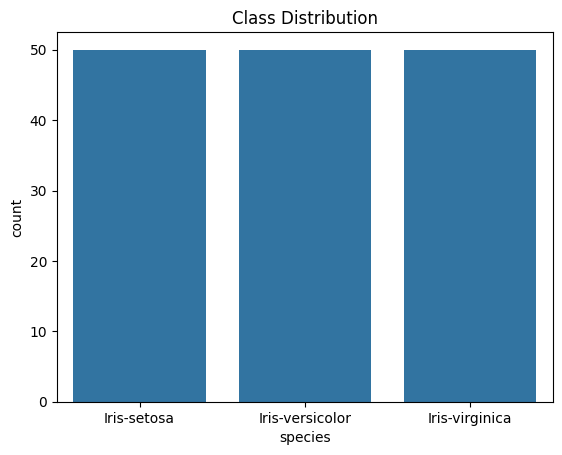

In [4]:
sns.countplot(x='species', data=df)
plt.title("Class Distribution")
plt.show()


# Correlation Heatmap

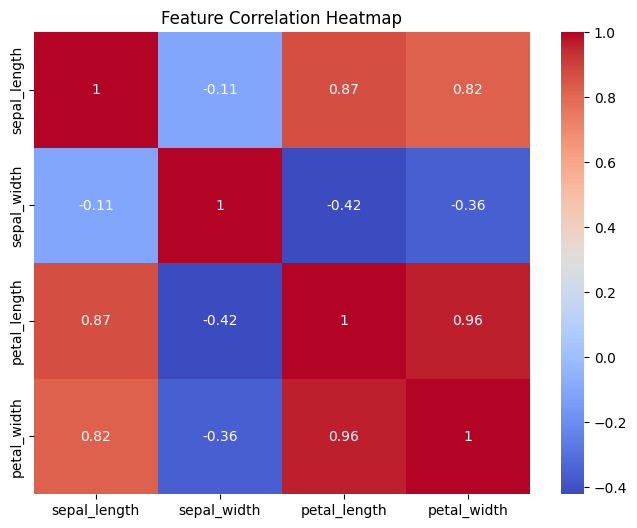

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# Pairplot

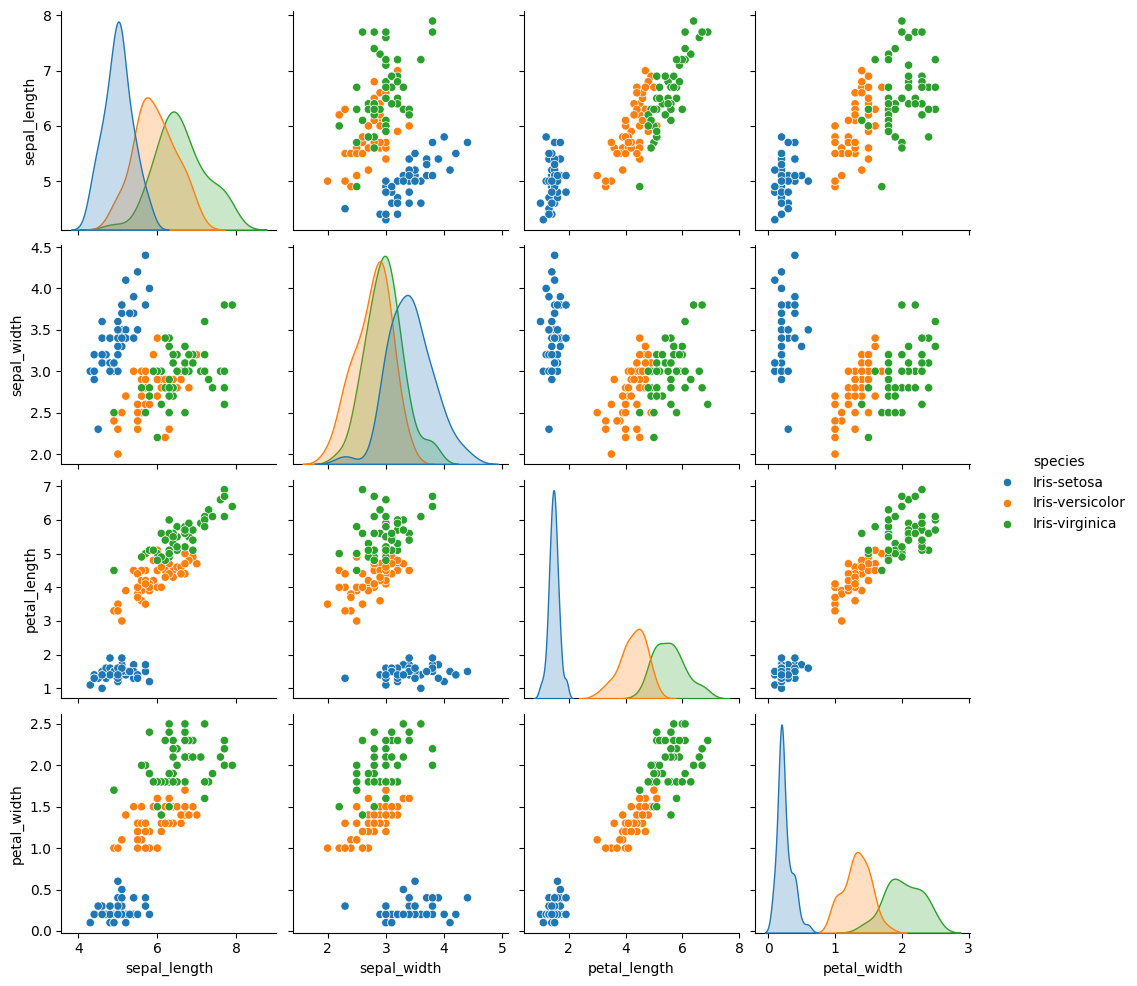

In [6]:
sns.pairplot(df, hue='species')
plt.show()


# Dataset Overview & Metadata Analysis

In [7]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nUnique Values in Each Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Dataset Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Unique Values in Each Column:
sepal_length: 35
sepal_width: 23
petal_length: 43
petal_width: 22
species: 3


# Missing Value Heatmap

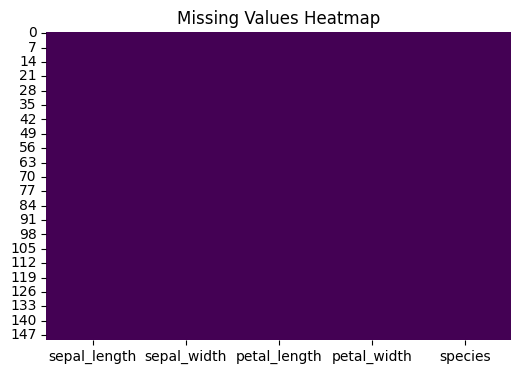

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


# Class Imbalance Analysis

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


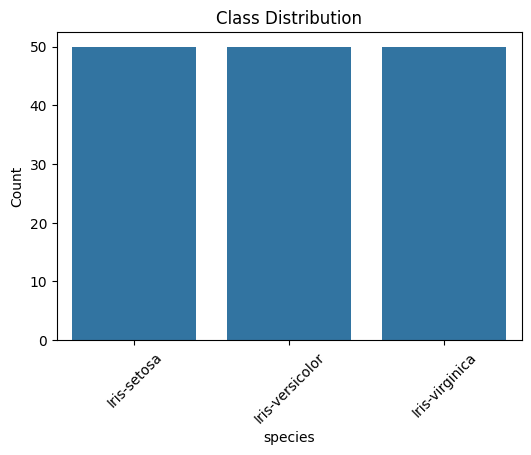

In [9]:
class_counts = df['species'].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Univariate Analysis (Feature Distribution)

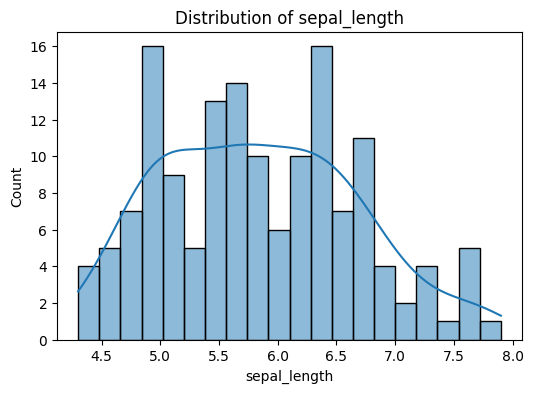

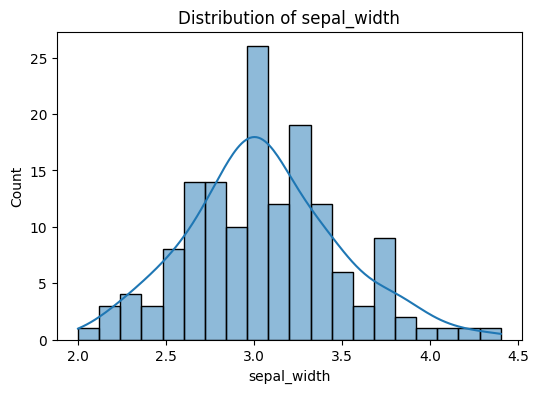

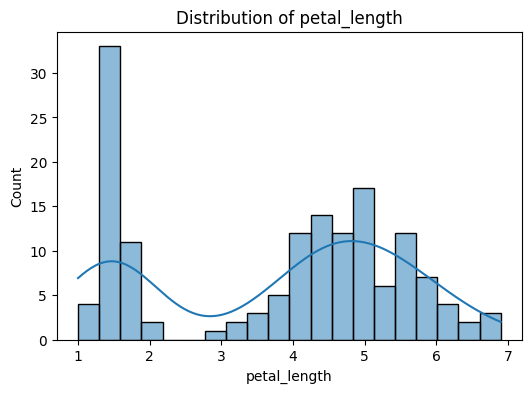

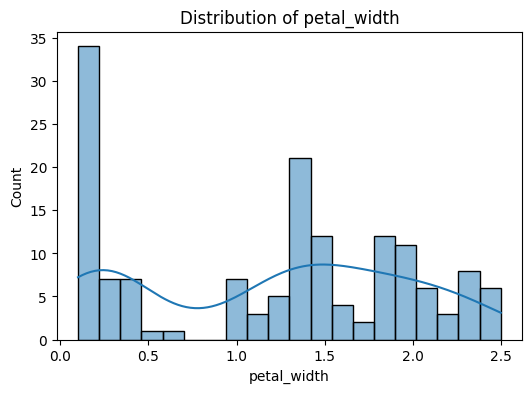

In [10]:
features = df.drop("species", axis=1).columns

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True, bins=20)
    plt.title(f"Distribution of {feature}")
    plt.show()


# Boxplots by Species (Very Important)

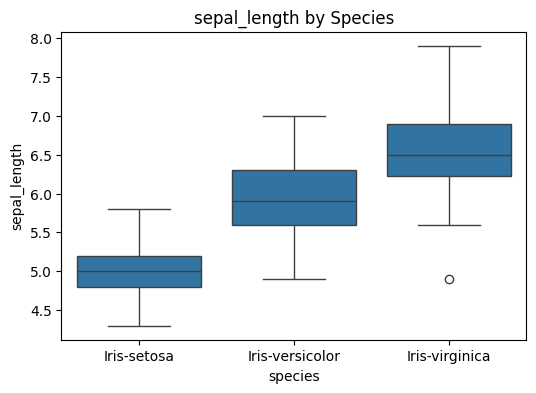

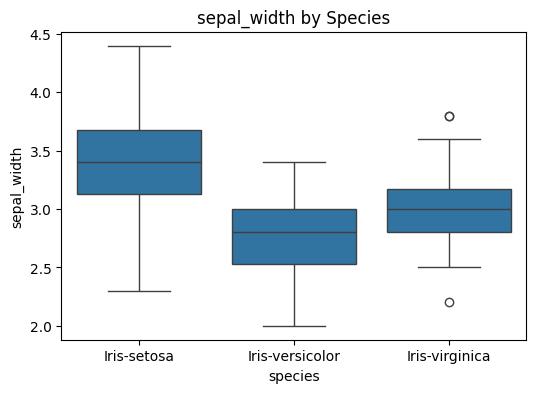

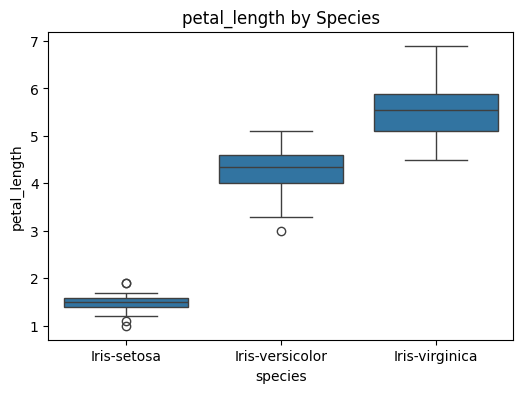

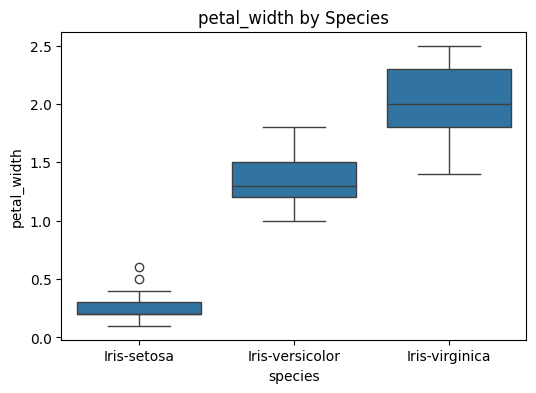

In [11]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f"{feature} by Species")
    plt.show()


# Multivariate Analysis – Pairplot (High Value Visualization)

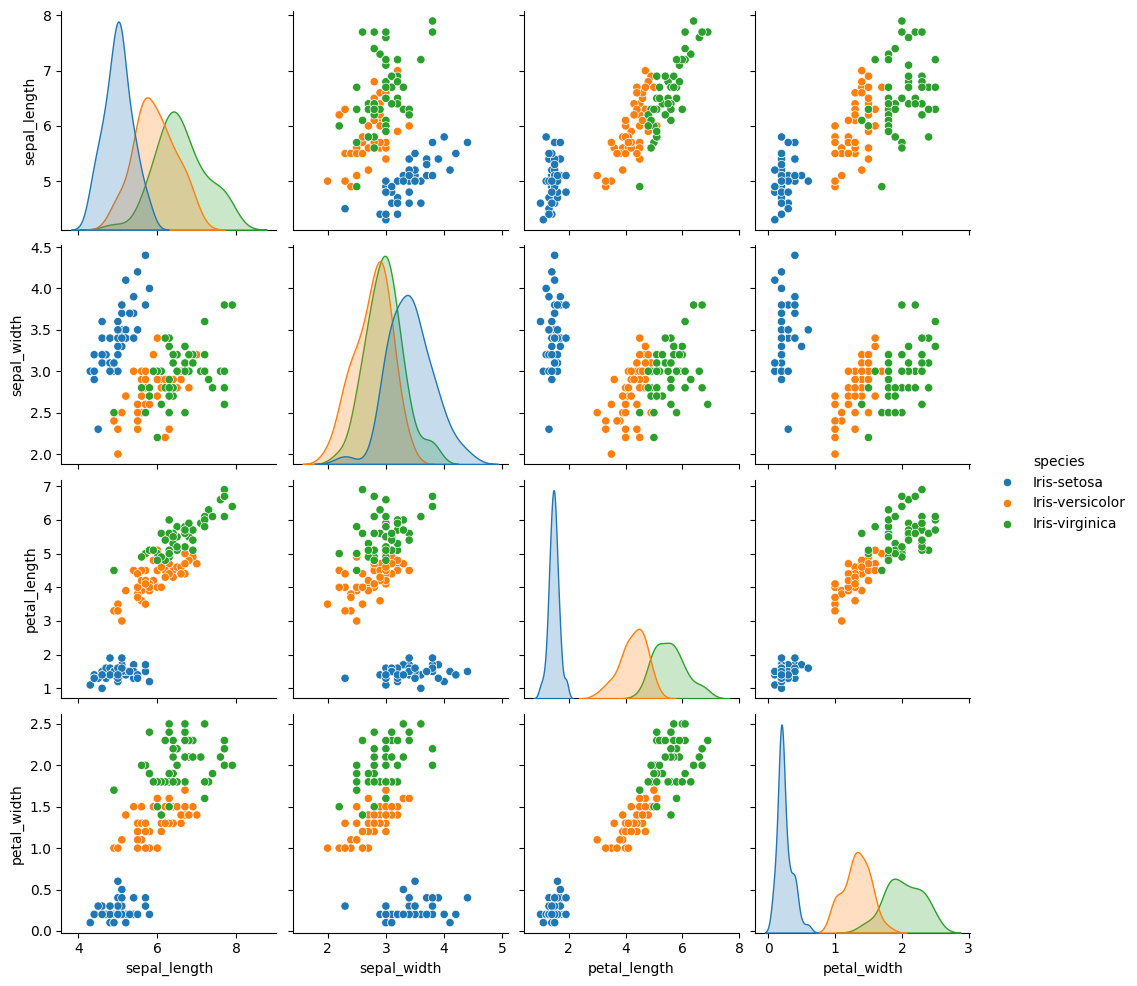

In [12]:
sns.pairplot(df, hue='species', diag_kind='kde')
plt.show()


# correlation Matrix with Interpretation

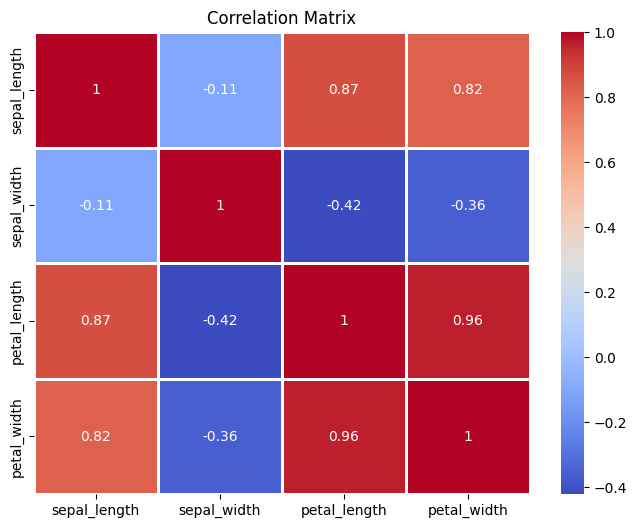

In [13]:
plt.figure(figsize=(8,6))
corr = df.drop("species", axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=1)
plt.title("Correlation Matrix")
plt.show()


# Advanced Feature Relationships (Scatterplots)

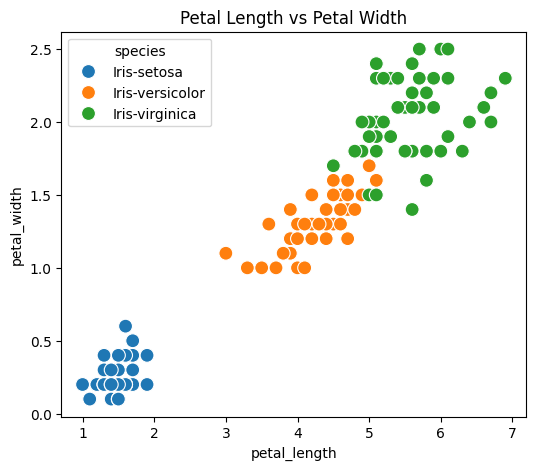

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="petal_length",
    y="petal_width",
    hue="species",
    data=df,
    s=100
)
plt.title("Petal Length vs Petal Width")
plt.show()


# Statistical Analysis (Advanced Touch)

In [15]:
grouped_stats = df.groupby("species").agg(['mean', 'std', 'min', 'max'])
grouped_stats


sepal_length                     sepal_width                 \
                        mean       std  min  max        mean       std  min   
species                                                                       
Iris-setosa            5.006  0.352490  4.3  5.8       3.418  0.381024  2.3   
Iris-versicolor        5.936  0.516171  4.9  7.0       2.770  0.313798  2.0   
Iris-virginica         6.588  0.635880  4.9  7.9       2.974  0.322497  2.2   

                     petal_length                     petal_width            \
                 max         mean       std  min  max        mean       std   
species                                                                       
Iris-setosa      4.4        1.464  0.173511  1.0  1.9       0.244  0.107210   
Iris-versicolor  3.4        4.260  0.469911  3.0  5.1       1.326  0.197753   
Iris-virginica   3.8        5.552  0.551895  4.5  6.9       2.026  0.274650   

                           
                 min  max  
species                    
Iris-setosa      0.1  0.6  
Iris-versicolor  1.0  1.8  
Iris-virginica   1.4  2.5

# Outlier Detection

In [16]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers

for feature in features:
    outliers = detect_outliers(df, feature)
    print(f"{feature} - Outliers Count:", len(outliers))


sepal_length - Outliers Count: 0
sepal_width - Outliers Count: 4
petal_length - Outliers Count: 0
petal_width - Outliers Count: 0


# Distribution by Species

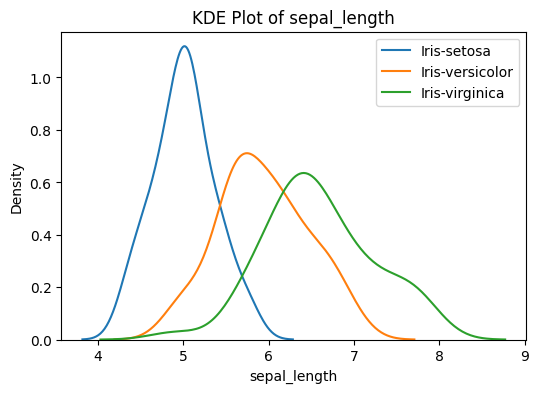

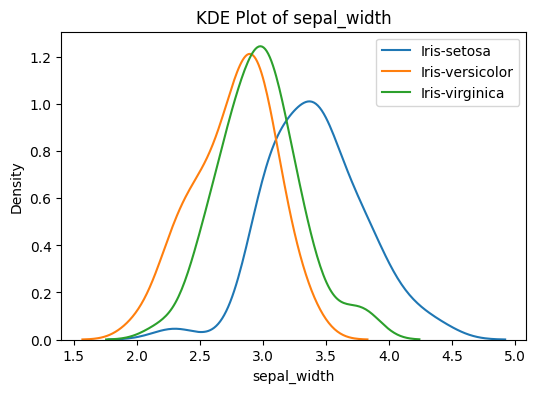

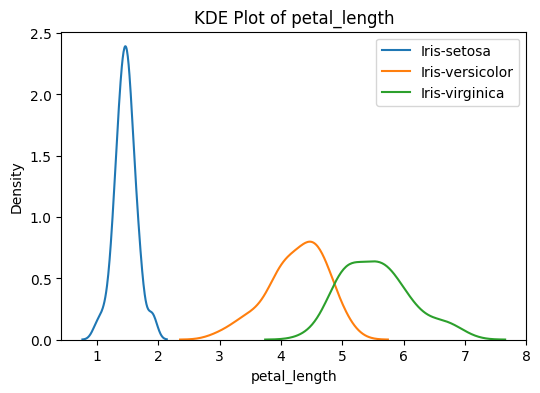

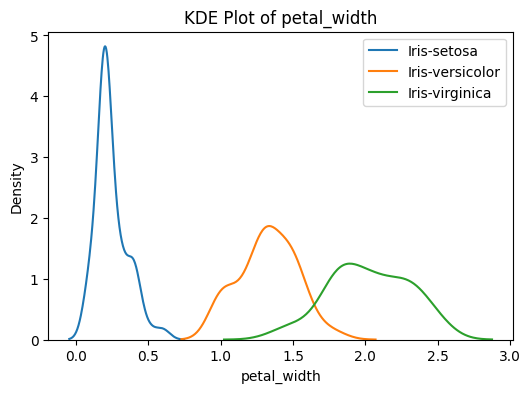

In [17]:
for feature in features:
    plt.figure(figsize=(6,4))
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        sns.kdeplot(subset[feature], label=species)
    
    plt.title(f"KDE Plot of {feature}")
    plt.legend()
    plt.show()


# PCA Visualization

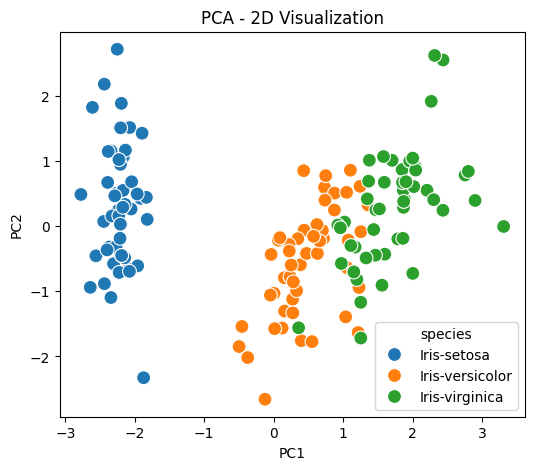

Explained Variance Ratio: [0.72770452 0.23030523]


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df.drop("species", axis=1))

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['species'] = df['species']

plt.figure(figsize=(6,5))
sns.scatterplot(x='PC1', y='PC2', hue='species', data=pca_df, s=100)
plt.title("PCA - 2D Visualization")
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


# Statistical

In [19]:
from scipy.stats import f_oneway

for feature in features:
    groups = [df[df['species']==s][feature] for s in df['species'].unique()]
    stat, p = f_oneway(*groups)
    print(f"{feature} -> p-value: {p}")


sepal_length -> p-value: 1.6696691907693826e-31
sepal_width -> p-value: 1.3279165184572242e-16
petal_length -> p-value: 3.0519758018278374e-91
petal_width -> p-value: 4.376956957488959e-85


# Feature Engineering

In [20]:
# Encode target variable
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

X = df.drop("species", axis=1)
y = df["species"]


# Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Build Multiple ML Models

In [22]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


# Cross Validation Comparison

In [23]:
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(f"{name} Accuracy: {scores.mean():.4f}")


Logistic Regression Accuracy: 0.9583
Random Forest Accuracy: 0.9500
SVM Accuracy: 0.9667
KNN Accuracy: 0.9667


# Hyperparameter Tuning

In [24]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}


# Evaluate Best Model

In [25]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Confusion Matrix

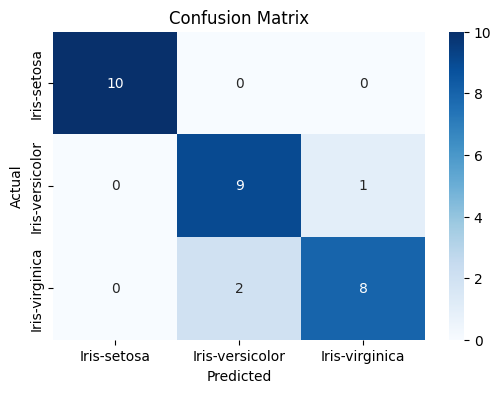

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Feature Importance

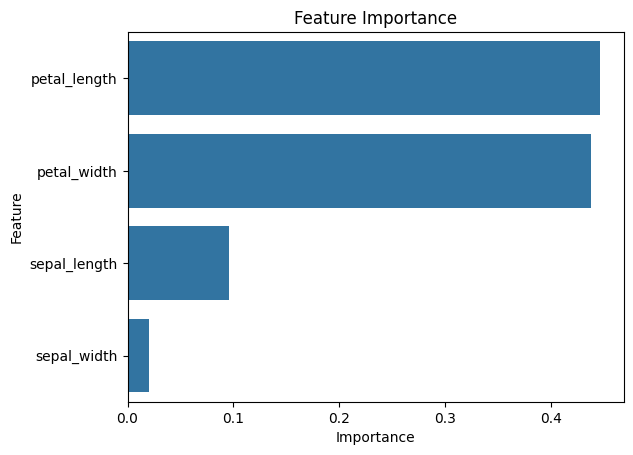

In [27]:
importances = best_model.named_steps['model'].feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()


# Save Model

In [29]:
import os
import joblib

# Create directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(best_model, "models/best_model.pkl")

print("Model Saved Successfully!")


Model Saved Successfully!


In [30]:
joblib.dump(best_model, "best_model.pkl")
print("Model Saved Successfully!")


Model Saved Successfully!


In [31]:
def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    model = joblib.load("models/best_model.pkl")
    
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = model.predict(input_data)
    
    return le.inverse_transform(prediction)[0]

# Example
predict_species(5.1, 3.5, 1.4, 0.2)


'Iris-setosa'